## Environment Setup

Install required packages (for Google Colab or fresh environments).

In [1]:
import Pkg
Pkg.add(url="https://github.com/TuringLang/SSMProblems.jl", subdir="SSMProblems")
Pkg.add(["AbstractMCMC", "Distributions", "Plots", "UnPack"])

     Cloning git-repo `https://github.com/TuringLang/SSMProblems.jl`
    Updating git-repo `https://github.com/TuringLang/SSMProblems.jl`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/work/SSMProblems.jl/SSMProblems.jl/SSMProblems/examples/kalman-filter/Project.toml`
  [26aad666] ~ SSMProblems v0.6.1 `~/work/SSMProblems.jl/SSMProblems.jl/SSMProblems` ⇒ v0.6.1 `https://github.com/TuringLang/SSMProblems.jl:SSMProblems#main` [loaded: `/home/runner/work/SSMProblems.jl/SSMProblems.jl/SSMProblems/src/SSMProblems.jl` (v0.6.1) expected `/home/runner/.julia/packages/SSMProblems/ZMavr/src/SSMProblems.jl` (v0.6.1)]
    Updating `~/work/SSMProblems.jl/SSMProblems.jl/SSMProblems/examples/kalman-filter/Manifest.toml`
  [26aad666] ~ SSMProblems v0.6.1 `~/work/SSMProblems.jl/SSMProblems.jl/SSMProblems` ⇒ v0.6.1 `https://github.com/TuringLang/SSMProblems.jl:SSMProblems#main` [loaded: `/home/runner/work/SSMProblems.jl/SSMProblems.jl/SSMProbl

# Kalman Filter


This example implements a Kalman filter for a linear Gaussian state space model using the
SSMProblems interface.

In [2]:
using AbstractMCMC
using Distributions
using LinearAlgebra
using Plots
using Random
using UnPack

using SSMProblems

## Model Definition

We start by defining structs to store the paramaters for our specific latent dynamics and
observation process.

The latent dynamics have the following form:
```
x[0] = z + ϵ,                 ϵ    ∼ N(0, P)
x[k] = Φx[k-1] + b + w[k],    w[k] ∼ N(0, Q)
```

We store all of these paramaters in a struct.

In [3]:
struct GaussianPrior{XT<:AbstractVector,ΣT<:AbstractMatrix} <: StatePrior
    x::XT
    Σ::ΣT
end

struct LinearGaussianLatentDynamics{
    ΦT<:AbstractMatrix,bT<:AbstractArray,QT<:AbstractMatrix
} <: LatentDynamics
    Φ::ΦT
    b::bT
    Q::QT
end

Note, that our specific dynamics should be subtypes of the abstract `LatentDynamics` type.
Importantly, consider the type parameters used. Whereas the type parameter(s) of our
struct can be whatever is/are most suitable, the type parameters of `LatentDynamics`
should reflect arithmetic type and the type of our latent state, respectively. In this
case, since we are considering a multi-dimensional problem, we use `Vector{T}` for the
latter.

Similarly, the observation process is defined by the following equation:
```
y[k] = Hx[k] + v[k],          v[k] ∼ N(0, R)
```

In [4]:
struct LinearGaussianObservationProcess{HT<:AbstractMatrix,RT<:AbstractMatrix} <:
       ObservationProcess
    H::HT
    R::RT
end

We then define general transition and observation distributions to be used in forward
simulation. If our model were time-inhomogenous, we could make our distribution functions
depend on the `step` argument or pass in control variables via keyword arguments.

Even if we did not require forward simulation (e.g. we were given observations), it is
still useful to define these methods as they allow us to run a particle filter on our
model with no additional implementation required. Although a Kalman filter would generally
be preferred in this linear Gaussian case, it may be of interest to compare the sampling
performance with a general particle filter.

In [5]:
function SSMProblems.distribution(prior::GaussianPrior; kwargs...)
    return MvNormal(prior.x, prior.Σ)
end

function SSMProblems.distribution(
    model::LinearGaussianLatentDynamics, step::Int, prev_state::AbstractVector; kwargs...
)
    return MvNormal(model.Φ * prev_state + model.b, model.Q)
end

function SSMProblems.distribution(
    model::LinearGaussianObservationProcess, step::Int, state::AbstractVector; kwargs...
)
    return MvNormal(model.H * state, model.R)
end

## Filtering Algorithm

We define a concrete type to represent our sampling algorithm. This is used for dispatch
to, say, distinguish from using a generic particle filter.

In [6]:
struct KalmanFilter end

A Kalman filter is only valid for linear Gaussian state space models, so we define an
alias for an SSM with linear Gaussian latent dynamics and observation process, which will
be used to dispatch to the correct method.

In [7]:
const LinearGaussianSSM = StateSpaceModel{
    <:GaussianPrior,<:LinearGaussianLatentDynamics,<:LinearGaussianObservationProcess
};

We then define a method for the `sample` function. This is a standardised interface which
requires the model we are sampling from, the sampling algorithm as well as the
observations and any keyword arguments which will be passed to the distribution functions.

Note, that if our model were time-inhomogenous, we we need our model vectors/matrices
(e.g. A, b) to depend on the step variable `t` or the control variables. To make our
filtering algorithm generic, we should not handle this within the `sample` function.
Instead, we would pass this responsibility to the model by defining functions of the form
`calc_A(model, t; kwargs...)` etc.

In [8]:
function AbstractMCMC.sample(
    model::LinearGaussianSSM, ::KalmanFilter, observations::AbstractVector; kwargs...
)
    # Extract parameters
    @unpack Φ, b, Q = model.dyn
    @unpack H, R = model.obs
    @unpack x, Σ = model.prior

    T = length(observations)
    x_filts = Vector{typeof(x)}(undef, T)
    Σ_filts = Vector{typeof(Σ)}(undef, T)

    for t in 1:T
        # Prediction step
        x = Φ * x + b
        Σ = Φ * Σ * Φ' + Q

        # Update step
        y = observations[t]
        K = Σ * H' / (H * Σ * H' + R)
        x = x + K * (y - H * x)
        Σ = Σ - K * H * Σ

        x_filts[t] = x
        Σ_filts[t] = Σ
    end

    return x_filts, Σ_filts
end

## Simulation and Filtering

We define the parameters for our model as so.

In [9]:
SEED = 1;
T = 100;
x = [-1.0, 1.0];
Σ = Matrix(1.0I, 2, 2);
Φ = [0.8 0.2; -0.1 0.8];
b = zeros(2);
Q = [0.2 0.0; 0.0 0.5];
H = [1.0 0.0;];
R = Matrix(0.3I, 1, 1);

We can then construct the latent dynamics and observation process, before combining these
to form a state space model.

In [10]:
prior = GaussianPrior(x, Σ);
dyn = LinearGaussianLatentDynamics(Φ, b, Q);
obs = LinearGaussianObservationProcess(H, R);
model = StateSpaceModel(prior, dyn, obs);

Synthetic data can be generated by directly sampling from the model. This calls a utility
function from the `SSMProblems` package, which in turn, calls the three distribution
functions we defined above.

In [11]:
rng = MersenneTwister(SEED);
x0, xs, ys = sample(rng, model, T);

@code_warntype sample(rng, model, T)

We can then run the Kalman filter and plot the filtering results against the ground truth.

In [12]:
x_filts, P_filts = AbstractMCMC.sample(model, KalmanFilter(), ys);

@code_warntype AbstractMCMC.sample(model, KalmanFilter(), ys);

Plot trajectory for first dimension

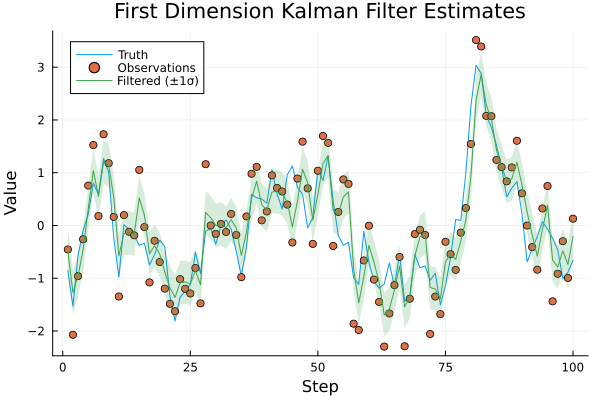

In [13]:
p = plot(; title="First Dimension Kalman Filter Estimates", xlabel="Step", ylabel="Value")
plot!(p, first.(xs); label="Truth")
scatter!(p, first.(ys); label="Observations")
plot!(
    p,
    1:T,
    first.(x_filts);
    ribbon=sqrt.(first.(P_filts)),
    label="Filtered (±1σ)",
    fillalpha=0.2,
)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*